In [1]:
import os
import sys
import argparse

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=500, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
xtrain, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

writer = SummaryWriter(log_dir=f"runs/genrkm_{ct}")

In [5]:
def kPCA(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def rkm_loss(output1, X):
    h, s = kPCA(output1)
    U = torch.mm(output1.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), h.t()))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), h.t())))
    f3 = 0.5 * torch.trace(torch.mm(U.t(), U))

    # Reconstruction losses
    mse = torch.nn.MSELoss()
    img_loss = mse(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim))

    f4 = img_loss

    loss = -f1 + f3 + f2 + 0.5 * (-f1 + f3 + f2) ** 2 + opt.c_accu * f4
    return loss

In [7]:
net1 = Net1(opt).double().to(opt.device)
net3 = Net3(opt).double().to(opt.device)

In [8]:
params = list(net1.parameters()) + list(net3.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)
loss_history = []

In [9]:
l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost
start = datetime.now()
global_step = 0

while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    avg_loss = 0
    for i, (datax, datay) in enumerate(xtrain):
        if i < math.ceil(opt.N / opt.mb_size):
            datax = datax.to(opt.device)
            output1 = net1(datax)

            loss = rkm_loss(output1, datax)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            writer.add_scalar("Loss/train_batch", loss.item(), global_step)
            global_step += 1
            avg_loss += loss.detach().cpu().numpy()
        else:
            break
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)

    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)
    print(t, cost)
    t += 1
    loss_history.append(cost)
    writer.add_scalar("Loss/train_epoch", cost, t)
print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

1 419.47228843793636
2 175.84350654105077
3 125.70102806382069
4 93.56066372929064
5 71.69963985637277
6 58.5663387129615
7 50.17014645460119
8 44.80713742756856
9 40.56492609624405
10 37.52950673714618
11 34.950279835611056
12 33.158256040214425
13 31.39011099512844
14 30.23352258880813
15 29.072230179347944
16 28.388447341896242
17 27.5552985476267
18 26.838237837235656
19 26.275719565007368
20 25.692100538764624
21 25.114457301104128
22 24.814712376441932
23 24.194584115146814
24 23.955833740258594
25 23.48507291063175
26 23.176575479096886
27 23.15945277124227
28 22.35357747009115
29 22.420416629795398
30 22.50188996714182
31 21.761866827381827
32 21.63847385571353
33 21.540363372824878
34 21.510106111318986
35 21.167556940988444
36 20.983119481372178
37 20.7167540624378
38 20.53179609621518
39 20.15070801430016
40 19.974827942343264
41 20.29375224303791
42 20.080467505696586
43 19.90460452901286
44 19.47842354579947
45 19.483259259388273
46 19.16512330796942
47 19.26808127432603
4

In [ ]:
# Save loss_history in a csv file
import pandas as pd

df_loss_history = pd.DataFrame(loss_history, columns=['loss'])
df_loss_history.to_csv('loss_history.csv', index=False)

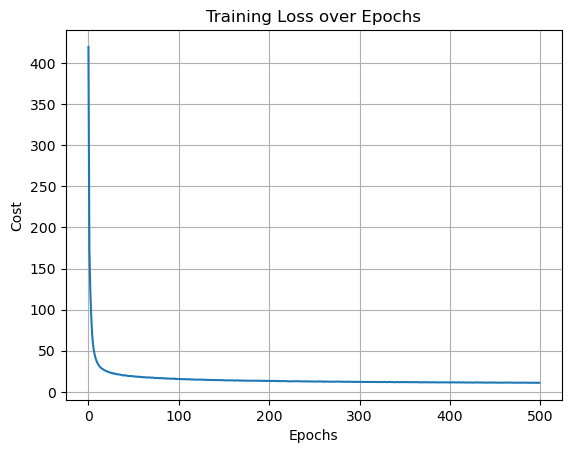

In [10]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Training Loss over Epochs')
plt.grid()
plt.show()

In [12]:
if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
    net1.load_state_dict(sd_mdl['net1_state_dict'])
    net3.load_state_dict(sd_mdl['net3_state_dict'])

U, h, s = final_compute_1V(opt, net1, kPCA)

/opt/anaconda3/envs/MT-GenRKM/lib/python3.12/site-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [13]:
torch.save({'net1': net1,
            'net3': net3,

            'net1_state_dict': net1.state_dict(),
            'net3_state_dict': net3.state_dict(),

            'datax': datax,
            'datay': datay,

            'h': h,
            'opt': opt, 's': s, 'U': U}, 'out/{}'.format(dirs.dirout))

In [ ]:
# model = torch.load('out/Final.tar', weights_only=False)

# U = model['U']
# h = model['h']
# s = model['s']

# net1 = model['net1']
# net3 = model['net3']

# datax = model['datax']

## Evaluation

In [14]:
recon_loss = torch.nn.MSELoss(reduction='mean')

net1.eval()
net3.eval()

digit_loss_sum = 0.
label_loss_sum = 0.
loss_sum = 0.
n = 0

out_data_x_test, out_data_y_test = [], []
in_data_x_test, in_data_y_test = [], []

with torch.no_grad():
    for i, (datax, datay) in enumerate(xtest):
        datax = datax.to(opt.device)

        in_data_x_test.append(datax.cpu().numpy())

        x_en = net1(datax)

        _h, _ = kPCA(x_en)

        U = torch.mm(torch.t(x_en), _h)

        x_tilde = net3(torch.mm(_h, torch.t(U)))

        out_data_x_test.append(x_tilde.cpu().numpy())

        B = datax.size(0)

        digit_loss = recon_loss(x_tilde.view(B, -1), datax.view(B, -1))

        digit_loss_sum += digit_loss.item() * B

        n += B

digit_loss = digit_loss_sum / n

print("Digit Reconstruction Loss:", digit_loss)

Digit Reconstruction Loss: 0.010276513197281038


## Visual Inspection

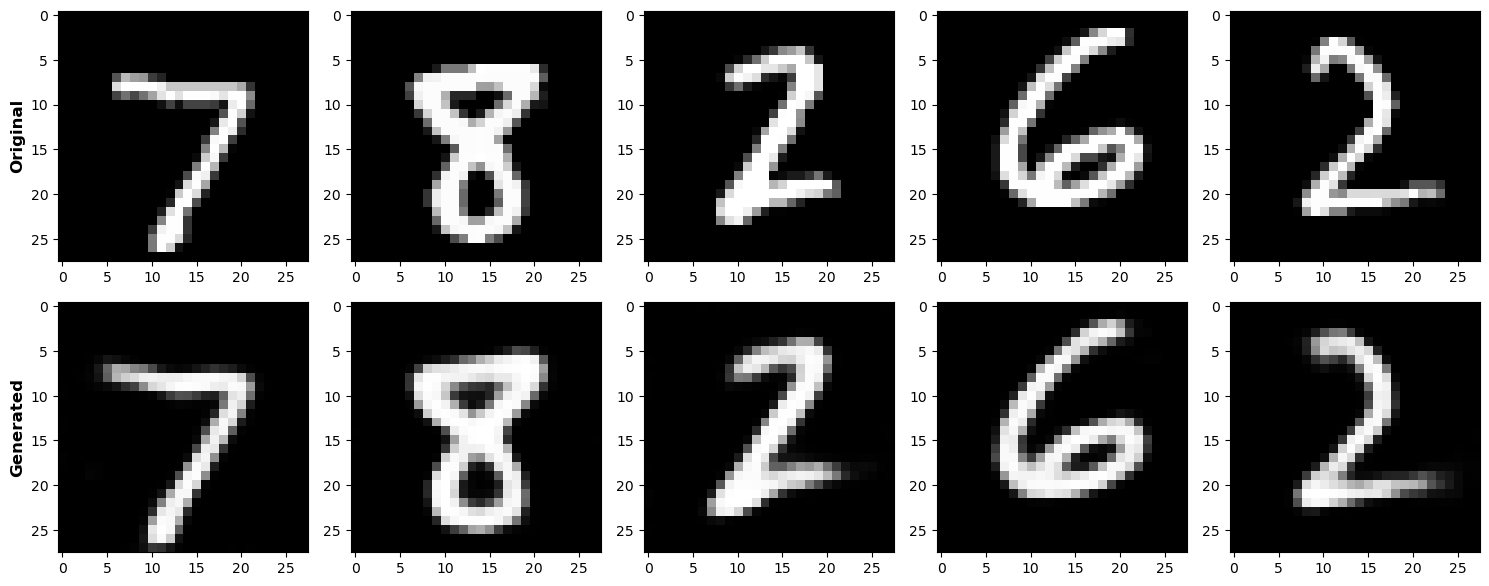

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx in range(5):    
    axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Generated', fontsize=12, fontweight='bold')

    axes[0, idx].imshow(in_data_x_test[idx][0].reshape(28, 28), cmap='gray')

    axes[1, idx].imshow(out_data_x_test[idx][0].reshape(28, 28), cmap='gray')

plt.tight_layout()
plt.show()

## Disentanglement

In [16]:
Zs = []

with torch.no_grad():
    for datax, datay in xtrain:
        datay = datay.to(opt.device)
        
        Zs.append(datay.cpu().numpy())

C = h.detach().cpu().numpy()
Z = np.concatenate(Zs, axis=0)[:10000]

factor_types = ["discrete"] * Z.shape[1]

In [17]:
C.shape, Z.shape

((10000, 24), (10000, 10))

In [18]:
res = compute_dci(C, Z, factor_types, probe="lasso")
report_dci(res, title='Combined DCI Scores')

--- Combined DCI Scores ---
 > Disentanglement: 0.1326
 > Completeness: 0.1043
 > Informativeness: 0.9


- Low D & C -> Did not to learn to store digits based on value, it **organized its latent space around other factors**
- High I -> The representation did store the digits wellI men

-> Other scores must be used

## IRS

In [19]:
irs_results = compute_irs(C, Z)

print(f'--- IRS Scores ---')
print(f' > IRS Disentanglement: {round(irs_results["IRS"], 4)}')

--- IRS Scores ---
 > IRS Disentanglement: 0.3825


### MIG

In [20]:
mig_res = compute_mig(C, Z)
print(f'--- MIG Scores ---')
print(f' > MIG: {round(mig_res["MIG"], 4)}')

--- MIG Scores ---
 > MIG: 0.0004
